# Phase 2 — Feature Engineering

This notebook answers the **Phase 2 — Feature Engineering** research questions from the project [README](../README.md#phase-2--feature-engineering):

1. Do expense-to-income ratios generalize better across income levels than raw expense values?
2. How should `Occupation` and `City_Tier` be encoded?
3. Which features require scaling, and does that depend on the downstream model?
4. Are any features redundant or highly collinear?

It builds directly on `01_eda_and_leakage_check.ipynb`: the leakage columns identified there (`Disposable_Income`, `Desired_Savings`, `Desired_Savings_Percentage`) are excluded from the feature set from the start, and the strong income↔expense correlation found in Phase 1 is exactly what motivates Question 1 here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ["Disposable_Income", "Desired_Savings", "Desired_Savings_Percentage"]
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

expense_cols = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport", "Eating_Out",
    "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous",
]
print(f"Shape: {df.shape}")
df.head()

Shape: (20000, 28)


,Income,Age,Dependents,Occupation,City_Tier,Rent,Loan_Repayment,Insurance,Groceries,Transport,Eating_Out,Entertainment,Utilities,Healthcare,Education,Miscellaneous,Desired_Savings_Percentage,Desired_Savings,Disposable_Income,Potential_Savings_Groceries,Potential_Savings_Transport,Potential_Savings_Eating_Out,Potential_Savings_Entertainment,Potential_Savings_Utilities,Potential_Savings_Healthcare,Potential_Savings_Education,Potential_Savings_Miscellaneous,Goal_Met
0,44637.249636,49,0,Self_Employed,Tier_1,13391.174891,0.000000,2206.490129,6658.768341,2636.970696,1651.801726,1536.184255,2911.792231,1546.914539,0.000000,831.525120,13.890948,6200.537192,11265.627707,1685.696222,328.895281,465.769172,195.151320,678.292859,67.682471,0.000000,85.735517,1
1,26858.596592,34,2,Retired,Tier_2,5371.719318,0.000000,869.522617,2818.444460,1543.018778,649.378103,1050.241738,1626.143346,1137.351325,1551.723167,564.235007,7.160376,1923.176434,9676.818733,540.306561,119.347139,141.866089,234.131168,286.668408,6.603212,56.306874,97.388606,1
2,50367.605084,35,1,Student,Tier_3,7555.140763,4612.103386,2201.800050,6313.222081,3221.396403,1513.814376,1723.306926,3368.457108,2178.515847,3160.026299,628.371220,13.997808,7050.360422,13891.450624,1466.073984,473.549752,410.857129,459.965256,488.383423,7.290892,106.653597,138.542422,1
3,101455.600247,21,0,Self_Employed,Tier_3,15218.340037,6809.441427,4889.418087,14690.149363,7106.130005,5040.249158,2858.194240,6128.550387,4571.118217,0.000000,2526.055712,16.455440,16694.965136,31617.953615,1875.932770,762.020789,1241.017448,320.190594,1389.815033,193.502754,0.000000,296.041183,1
4,24875.283548,52,4,Professional,Tier_2,4975.056710,3112.609398,635.907170,3034.329665,1276.155163,692.827225,660.186852,1092.689024,1169.095816,1445.215694,515.510300,7.533982,1874.099434,6265.700532,788.953124,68.160766,61.712505,187.173750,194.117130,47.294591,67.388120,96.557076,1


## 1. Do expense-to-income ratios generalize better than raw expense values?

Phase 1 found every raw expense column strongly correlated with `Income` (r up to 0.99). That means a raw expense value mostly encodes *how much this person earns*, not *how they choose to spend* — a model trained on raw values partly re-learns income rather than a genuinely transferable spending pattern. Converting each expense to a **ratio of income** (`category / Income`) should strip out that income-driven component.

In [2]:
ratio_cols = []
for c in expense_cols:
    ratio_col = f"{c}_Ratio"
    df[ratio_col] = df[c] / df["Income"]
    ratio_cols.append(ratio_col)

raw_corr = df[expense_cols].corrwith(df["Income"]).rename("raw_corr_with_income")
ratio_corr = df[ratio_cols].corrwith(df["Income"]).rename("ratio_corr_with_income")
ratio_corr.index = expense_cols  # align for side-by-side comparison

comparison = pd.concat([raw_corr, ratio_corr], axis=1)
comparison["abs_reduction"] = comparison["raw_corr_with_income"].abs() - comparison["ratio_corr_with_income"].abs()
comparison.sort_values("raw_corr_with_income", ascending=False)

,raw_corr_with_income,ratio_corr_with_income,abs_reduction
Groceries,0.985717,-0.005825,0.979892
Transport,0.981955,0.003764,0.978191
Healthcare,0.978838,0.006516,0.972322
Utilities,0.964414,0.005839,0.958575
Insurance,0.944395,0.004306,0.940089
Entertainment,0.943594,-0.006862,0.936732
Eating_Out,0.939673,0.008285,0.931387
Rent,0.939370,-0.008916,0.930453
Miscellaneous,0.919519,-0.012333,0.907186
Education,0.794558,0.004589,0.789969


In [3]:
df["Income_Quartile"] = pd.qcut(df["Income"], 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])

quartile_means = df.groupby("Income_Quartile", observed=True)[["Groceries", "Groceries_Ratio"]].mean()
quartile_means.columns = ["Mean raw Groceries (₹)", "Mean Groceries_Ratio"]
quartile_means

,Mean raw Groceries (₹),Mean Groceries_Ratio
Income_Quartile,,
Q1 (low),1462.784142,0.125211
Q2,2939.428443,0.125093
Q3,4954.281640,0.125637
Q4 (high),11466.175746,0.125102


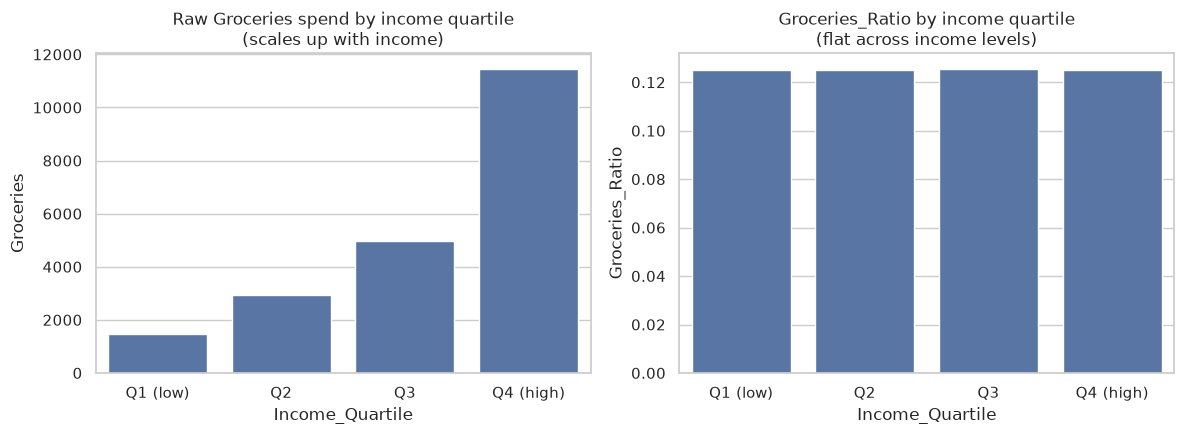

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x="Income_Quartile", y="Groceries", data=df, ax=axes[0], errorbar=None)
axes[0].set_title("Raw Groceries spend by income quartile\n(scales up with income)")
sns.barplot(x="Income_Quartile", y="Groceries_Ratio", data=df, ax=axes[1], errorbar=None)
axes[1].set_title("Groceries_Ratio by income quartile\n(flat across income levels)")
fig.tight_layout()
plt.show()

**Answer:** Yes, decisively. Raw expense columns correlate with `Income` at r ≈ 0.79–0.99; after converting to ratios, that correlation collapses to essentially **zero** (|r| < 0.01 for every category). The quartile breakdown makes the mechanism concrete: mean raw `Groceries` spend rises roughly **8×** from the lowest to the highest income quartile, while mean `Groceries_Ratio` stays flat at ≈0.125 in every quartile. Ratios isolate the actual *spending-mix* signal (relevant to personas and to predicting `Goal_Met` independent of income level) from the income level itself, which is already captured separately by the `Income` feature — so **expense-to-income ratios should replace the raw expense columns** in the model's feature set, with `Income` kept as its own feature.

## 2. How should `Occupation` and `City_Tier` be encoded?

In [5]:
print("Occupation categories:", df["Occupation"].value_counts().to_dict())
print("City_Tier categories:", df["City_Tier"].value_counts().to_dict())

income_by_occupation = df.groupby("Occupation", observed=True)["Income"].mean().sort_values(ascending=False)
income_by_tier = df.groupby("City_Tier", observed=True)["Income"].mean().reindex(["Tier_1", "Tier_2", "Tier_3"])
print("\nMean Income by Occupation:\n", income_by_occupation)
print("\nMean Income by City_Tier:\n", income_by_tier)

Occupation categories: {'Retired': 5019, 'Professional': 5011, 'Student': 5003, 'Self_Employed': 4967}
City_Tier categories: {'Tier_2': 10068, 'Tier_1': 5934, 'Tier_3': 3998}

Mean Income by Occupation:
 Occupation
Professional     42020.474941
Student          41829.582625
Self_Employed    41829.155645
Retired          40666.767123
Name: Income, dtype: float64

Mean Income by City_Tier:
 City_Tier
Tier_1    41068.390063
Tier_2    41713.210706
Tier_3    42031.388210
Name: Income, dtype: float64


Mean Rent_Ratio by City_Tier:
 City_Tier
Tier_1    0.30
Tier_2    0.20
Tier_3    0.15
Name: Rent_Ratio, dtype: float64


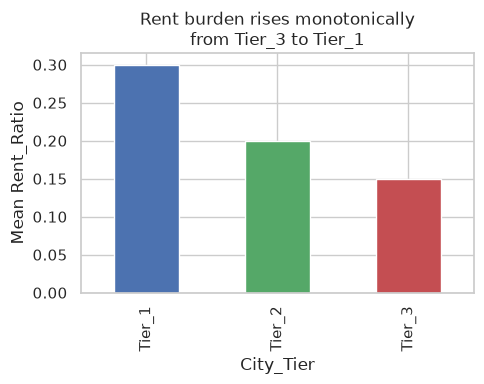

In [6]:
rent_ratio_by_tier = df.groupby("City_Tier", observed=True)["Rent_Ratio"].mean().reindex(["Tier_1", "Tier_2", "Tier_3"])
print("Mean Rent_Ratio by City_Tier:\n", rent_ratio_by_tier)

fig, ax = plt.subplots(figsize=(5, 4))
rent_ratio_by_tier.plot(kind="bar", ax=ax, color=["#4c72b0", "#55a868", "#c44e52"])
ax.set_ylabel("Mean Rent_Ratio")
ax.set_title("Rent burden rises monotonically\nfrom Tier_3 to Tier_1")
fig.tight_layout()
plt.show()

**Answer:**
- **`Occupation`** (4 levels: `Professional`, `Self_Employed`, `Student`, `Retired`) is a **purely nominal** category — mean `Income` is nearly identical across all four groups (₹40.7k–42.0k), so there's no natural ordering to exploit. It should be **one-hot encoded**.
- **`City_Tier`** (3 levels) does have a real-world order (`Tier_1` = largest/most expensive metro down to `Tier_3`), and the data reflects it clearly: mean `Rent_Ratio` moves monotonically from **0.30 (Tier_1) → 0.20 (Tier_2) → 0.15 (Tier_3)** — cost of living is baked directly into the rent burden. Despite that order, `City_Tier` should still default to **one-hot encoding**: with only 3 levels the one-hot cost is trivial, and one-hot avoids forcing linear/distance-based models (logistic regression, SVM, KNN) to assume the gap between Tier_1↔Tier_2 equals the gap between Tier_2↔Tier_3. An **ordinal encoding** (`Tier_1=1, Tier_2=2, Tier_3=3`) is a defensible, cheaper alternative specifically for tree-based models, which can already split on ordinal integers without assuming linearity and won't be hurt by imposing the order — but one-hot is the safer default across the model families under comparison in Phase 4.

## 3. Which features require scaling, and does it depend on the model?

In [7]:
feature_cols = ["Income", "Age", "Dependents"] + ratio_cols
scale_summary = df[feature_cols].agg(["mean", "std", "min", "max"]).T
scale_summary["range"] = scale_summary["max"] - scale_summary["min"]
scale_summary.sort_values("range", ascending=False)

,mean,std,min,max,range
Income,41585.496104,40014.540538,1301.187333,1.079728e+06,1.078427e+06
Age,41.031450,13.578725,18.000000,6.400000e+01,4.600000e+01
Dependents,1.995950,1.417616,0.000000,4.000000e+00,4.000000e+00
Loan_Repayment_Ratio,0.049905,0.067130,0.000000,1.999383e-01,1.999383e-01
Rent_Ratio,0.219675,0.055496,0.150000,3.000000e-01,1.500000e-01
Education_Ratio,0.059932,0.032868,0.000000,9.999374e-02,9.999374e-02
Groceries_Ratio,0.125261,0.014438,0.100001,1.499995e-01,4.999868e-02
Utilities_Ratio,0.060172,0.011569,0.040000,7.999917e-02,3.999895e-02
Transport_Ratio,0.065003,0.008640,0.050000,7.999949e-02,2.999929e-02
Entertainment_Ratio,0.034898,0.008686,0.020001,4.999933e-02,2.999787e-02


**Answer:** The candidate feature set spans wildly different scales — `Income` ranges from ~₹1.3k to ~₹1.08M (mean ≈ ₹41.6k, std ≈ ₹40.0k), `Age` ranges 18–64, `Dependents` ranges 0–4, while every `*_Ratio` feature is bounded roughly within 0–0.3. **`Income` in particular needs scaling** (e.g. `StandardScaler` or a log transform, given its right-skew from Phase 1) before it's combined with the ratio features in any model that cares about feature magnitude. Whether scaling matters **depends entirely on the downstream model family**:
- **Needs scaling:** Logistic Regression, SVM, KNN, and neural nets — these are distance- or gradient-magnitude-sensitive, so an unscaled `Income` column (magnitude in the tens of thousands) would dominate unscaled ratio columns (magnitude ~0.1) purely due to units, not actual predictive importance.
- **Scale-invariant:** Decision Tree, Random Forest, and gradient-boosted trees (XGBoost) split on thresholds per feature independently, so raw scale doesn't bias them — scaling is optional for these (harmless, but unnecessary).

Practically: build one scaled feature matrix (all numeric features standardized) for the linear/distance/NN models in Phase 4, and one unscaled version for the tree-based models, rather than assuming a single preprocessing pipeline fits every model family.

## 4. Are any features redundant or highly collinear?

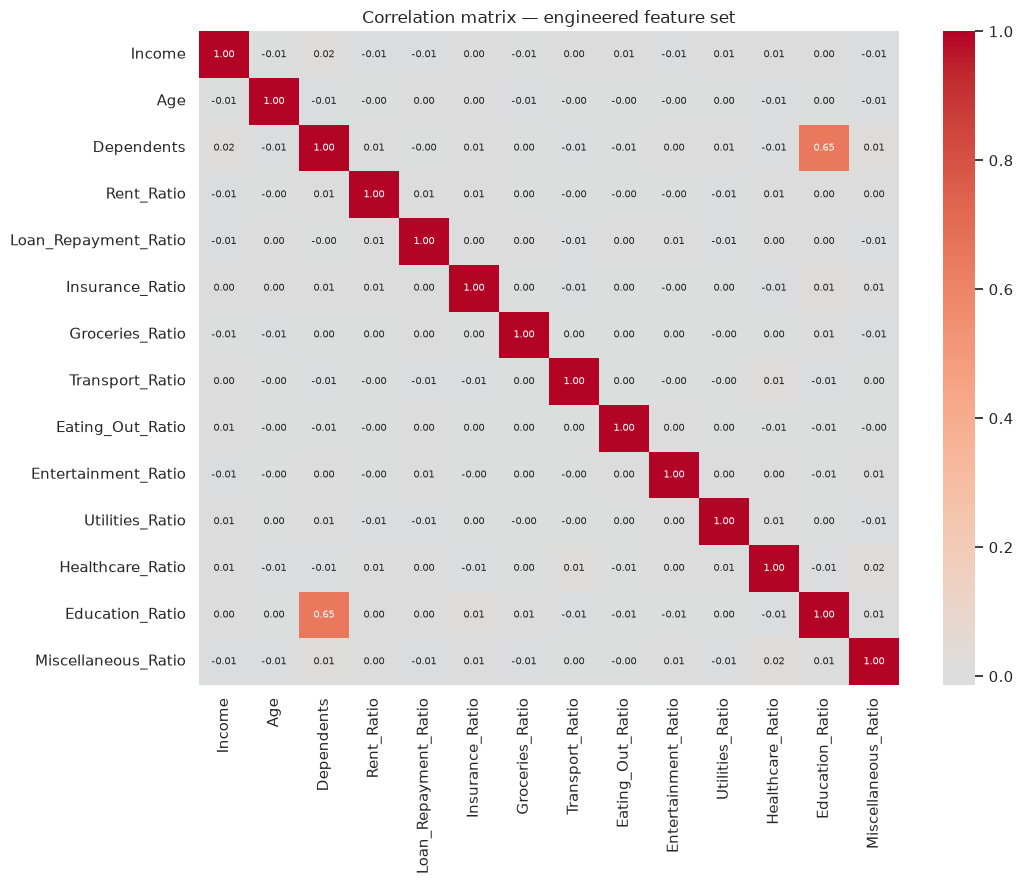

In [8]:
corr_matrix = df[["Income", "Age", "Dependents"] + ratio_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation matrix — engineered feature set")
fig.tight_layout()
plt.show()

In [9]:
X = df[["Income", "Age", "Dependents"] + ratio_cols].dropna()
X_with_const = sm.add_constant(X)  # VIF requires an intercept term, or scale-driven artifacts inflate every score
vif = pd.Series(
    [variance_inflation_factor(X_with_const.values, i) for i in range(1, X_with_const.shape[1])],
    index=X.columns,
    name="VIF",
).sort_values(ascending=False)
vif.to_frame()

,VIF
Dependents,1.731645
Education_Ratio,1.730875
Miscellaneous_Ratio,1.001186
Healthcare_Ratio,1.001127
Income,1.000978
Transport_Ratio,1.000575
Age,1.000515
Loan_Repayment_Ratio,1.000450
Insurance_Ratio,1.000395
Entertainment_Ratio,1.000368


**Answer:** Once expenses are converted to income ratios, the engineered feature set has **very little redundancy**. The correlation heatmap shows only one pair worth flagging — `Dependents` and `Education_Ratio` at r ≈ 0.65 (more dependents plausibly means proportionally more spent on education) — everything else among the ratio features is close to r ≈ 0. Variance Inflation Factors confirm this quantitatively: every feature scores **VIF ≈ 1.0**, except `Dependents` and `Education_Ratio` at **≈1.73** — both comfortably under the common VIF > 5 (let alone > 10) concern threshold. **Conclusion: no features need to be dropped for collinearity.** `Dependents` and `Education_Ratio` are correlated enough to be worth watching in Phase 5's explainability step (their individual SHAP contributions may partially trade off against each other), but not enough to justify removing either one now.

## Building the final Phase 2 feature set

Putting the four answers together: replace raw expenses with income ratios, one-hot encode `Occupation` and `City_Tier`, keep `Income`/`Age`/`Dependents` as numeric features (to be scaled downstream per model family), and drop the leakage columns plus the now-redundant raw expense columns.

In [10]:
engineered = pd.get_dummies(
    df[["Income", "Age", "Dependents", "Occupation", "City_Tier"] + ratio_cols + ["Goal_Met"]],
    columns=["Occupation", "City_Tier"],
    drop_first=False,
)

print(f"Final engineered feature matrix shape: {engineered.shape}")
print(f"Dropped as leakage: {LEAKAGE_COLS}")
print(f"Dropped as redundant (replaced by ratios): {expense_cols}")
engineered.head()

Final engineered feature matrix shape: (20000, 22)
Dropped as leakage: ['Disposable_Income', 'Desired_Savings', 'Desired_Savings_Percentage']
Dropped as redundant (replaced by ratios): ['Rent', 'Loan_Repayment', 'Insurance', 'Groceries', 'Transport', 'Eating_Out', 'Entertainment', 'Utilities', 'Healthcare', 'Education', 'Miscellaneous']


,Income,Age,Dependents,Rent_Ratio,Loan_Repayment_Ratio,Insurance_Ratio,Groceries_Ratio,Transport_Ratio,Eating_Out_Ratio,Entertainment_Ratio,Utilities_Ratio,Healthcare_Ratio,Education_Ratio,Miscellaneous_Ratio,Goal_Met,Occupation_Professional,Occupation_Retired,Occupation_Self_Employed,Occupation_Student,City_Tier_Tier_1,City_Tier_Tier_2,City_Tier_Tier_3
0,44637.249636,49,0,0.30,0.000000,0.049432,0.149175,0.059076,0.037005,0.034415,0.065232,0.034655,0.000000,0.018629,1,False,False,True,False,True,False,False
1,26858.596592,34,2,0.20,0.000000,0.032374,0.104936,0.057450,0.024178,0.039103,0.060545,0.042346,0.057774,0.021008,1,False,True,False,False,False,True,False
2,50367.605084,35,1,0.15,0.091569,0.043715,0.125343,0.063958,0.030055,0.034215,0.066877,0.043252,0.062739,0.012476,1,False,False,False,True,False,False,True
3,101455.600247,21,0,0.15,0.067117,0.048193,0.144794,0.070042,0.049679,0.028172,0.060406,0.045055,0.000000,0.024898,1,False,False,True,False,False,False,True
4,24875.283548,52,4,0.20,0.125129,0.025564,0.121982,0.051302,0.027852,0.026540,0.043927,0.046998,0.058098,0.020724,1,True,False,False,False,False,True,False


## Summary of Phase 2 answers

| # | Question | Answer |
|---|---|---|
| 1 | Ratios vs. raw values | Ratios generalize far better — raw expense↔income correlation of 0.79–0.99 collapses to ≈0 once converted to `category / Income`; raw values mostly re-encode income level, not spending behavior. |
| 2 | Encoding `Occupation` / `City_Tier` | Both one-hot encoded. `Occupation` is purely nominal (no income association across groups). `City_Tier` has a real, monotonic cost-of-living order (`Rent_Ratio` 0.30 → 0.20 → 0.15 from Tier_1 to Tier_3) but only 3 levels, so one-hot stays the safe default; ordinal encoding is a defensible cheaper alternative for tree-based models only. |
| 3 | Scaling | `Income` (and to a lesser extent `Age`) need scaling for linear/distance/NN models (Logistic Regression, SVM, KNN, neural nets); scaling is unnecessary (but harmless) for tree-based models (Decision Tree, Random Forest, XGBoost). Maintain both a scaled and an unscaled feature matrix for Phase 4. |
| 4 | Redundant / collinear features | Minimal redundancy after the ratio transform — every VIF ≈ 1.0 except `Dependents`/`Education_Ratio` at ≈1.73, well below any concerning threshold. No features need to be dropped. |

**Next:** Phase 3 — Baseline (`03_baseline_and_model_comparison.ipynb`), using this engineered feature set (ratios + one-hot categoricals + `Income`/`Age`/`Dependents`) with the leakage columns excluded, as established here and in Phase 1.